<a href="https://colab.research.google.com/github/Anushka-Pokhriyal/AQI_PREDICTION/blob/main/AQI_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving delhi-weather-aqi-2025.csv to delhi-weather-aqi-2025.csv


In [ ]:
import pandas as pd

df = pd.read_csv('delhi-weather-aqi-2025.csv')
df.head()


,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6


In [ ]:
# Z-Score Method
import numpy as np
from scipy import stats

data = np.array([10, 12, 14, 15, 18, 100])

z_scores = np.abs(stats.zscore(data))
outliers = data[z_scores > 3]

print("Outliers:", outliers)


Outliers: []


In [ ]:
# Basic inspection
df.head(), df.shape


(     date_ist time_ist     location      lat     lon  temp_c  humidity  \
 0  01/01/2025     0:00  Anand Vihar  28.6469  77.316     8.1       100   
 1  01/01/2025     1:00  Anand Vihar  28.6469  77.316     7.7       100   
 2  01/01/2025     2:00  Anand Vihar  28.6469  77.316     7.5       100   
 3  01/01/2025     3:00  Anand Vihar  28.6469  77.316     7.8        99   
 4  01/01/2025     4:00  Anand Vihar  28.6469  77.316     7.3       100   
 
    pressure_mb  windspeed_kph condition_text description  aqi_index  pm2_5  \
 0        995.4            2.9   Mainly clear  WMO Code 1        197  185.8   
 1        994.7            3.2       Overcast  WMO Code 3        198  174.6   
 2        994.3            4.5       Overcast  WMO Code 3        199  164.4   
 3        994.1            6.0       Overcast  WMO Code 3        200  156.5   
 4        993.8            6.8       Overcast  WMO Code 3        200  149.5   
 
     pm10    co   no2  
 0  188.6  1907  56.7  
 1  177.4  1669  44.8  


In [ ]:
df.columns


Index(['date_ist', 'time_ist', 'location', 'lat', 'lon', 'temp_c', 'humidity',
       'pressure_mb', 'windspeed_kph', 'condition_text', 'description',
       'aqi_index', 'pm2_5', 'pm10', 'co', 'no2'],
      dtype='object')

In [ ]:
# Always clean column names first
df.columns = df.columns.str.strip()

print("Available columns:")
print(df.columns.tolist())


Available columns:
['date_ist', 'time_ist', 'location', 'lat', 'lon', 'temp_c', 'humidity', 'pressure_mb', 'windspeed_kph', 'condition_text', 'description', 'aqi_index', 'pm2_5', 'pm10', 'co', 'no2']


In [ ]:
# Step 1: Create Date column safely
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

elif 'date_ist' in df.columns:
    df['Date'] = pd.to_datetime(df['date_ist'], errors='coerce')

elif 'time_ist' in df.columns:
    df['Date'] = pd.to_datetime(df['time_ist'], errors='coerce')

else:
    # Absolute fallback – never fails
    df['Date'] = pd.date_range(
        start='2024-01-01',
        periods=len(df),
        freq='H'
    )

# Step 2: Verify Date column exists
print("Date column created successfully")
print(df[['Date']].head())




Date column created successfully
        Date
0 2025-01-01
1 2025-01-01
2 2025-01-01
3 2025-01-01
4 2025-01-01


In [ ]:
# Convert existing Date column to datetime safely
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop invalid dates (if any)
df.dropna(subset=['Date'], inplace=True)

# Sort by date
df = df.sort_values('Date')

df[['Date']].head()


,Date
0,2025-01-01
92,2025-01-01
93,2025-01-01
94,2025-01-01
95,2025-01-01


In [ ]:
df.columns = df.columns.str.strip().str.replace(' ', '_')


In [ ]:
df = df.rename(columns={
    'temp_c': 'Temperature',
    'humidity': 'Humidity',
    'pressure_mb': 'Pressure',
    'windspeed_kph': 'WindSpeed',
    'pm2_5': 'PM2_5',
    'pm10': 'PM10',
    'co': 'CO',
    'no2': 'NO2',
    'aqi_index': 'AQI'
})


In [ ]:
df = df.drop(columns=[
    'location', 'lat', 'lon',
    'condition_text', 'description'
], errors='ignore')


In [ ]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 20736 entries, 0 to 49823
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date_ist     20736 non-null  object        
 1   time_ist     20736 non-null  object        
 2   Temperature  20736 non-null  float64       
 3   Humidity     20736 non-null  int64         
 4   Pressure     20736 non-null  float64       
 5   WindSpeed    20736 non-null  float64       
 6   AQI          20736 non-null  int64         
 7   PM2_5        20736 non-null  float64       
 8   PM10         20736 non-null  float64       
 9   CO           20736 non-null  int64         
 10  NO2          20736 non-null  float64       
 11  Date         20736 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(3), object(2)
memory usage: 2.1+ MB


,date_ist,time_ist,Temperature,Humidity,Pressure,WindSpeed,AQI,PM2_5,PM10,CO,NO2,Date
0,01/01/2025,0:00,8.1,100,995.4,2.9,197,185.8,188.6,1907,56.7,2025-01-01
92,01/01/2025,20:00,11.2,91,991.8,4.5,202,167.6,170.4,1673,68.6,2025-01-01
93,01/01/2025,21:00,11.1,91,991.9,5.8,200,168.6,171.8,1642,65.4,2025-01-01
94,01/01/2025,22:00,10.8,92,991.6,6.6,199,170.9,174.2,1586,59.7,2025-01-01
95,01/01/2025,23:00,10.4,93,991.3,7.1,198,170.4,173.2,1519,52.6,2025-01-01


In [ ]:
target_col = 'aqi_index'

In [ ]:
df.columns = df.columns.str.strip()
df.columns



Index(['date_ist', 'time_ist', 'Temperature', 'Humidity', 'Pressure',
       'WindSpeed', 'AQI', 'PM2_5', 'PM10', 'CO', 'NO2', 'Date'],
      dtype='object')

In [ ]:
df.drop(
    columns=[
        'location','lat','lon',
        'condition_text','description',
        'date_ist','time_ist'
    ],
    errors='ignore',
    inplace=True
)


In [ ]:
df.isnull().sum()


,0
Temperature,0
Humidity,0
Pressure,0
WindSpeed,0
AQI,0
PM2_5,0
PM10,0
CO,0
NO2,0
Date,0


In [ ]:
df.interpolate(inplace=True)
df.dropna(inplace=True)


In [ ]:
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['weekday'] = df['Date'].dt.weekday


In [ ]:
pollutants = ['PM2_5','PM10','CO','NO2']

for col in pollutants:
    df[col+'_roll3'] = df[col].rolling(3).mean()
    df[col+'_lag1'] = df[col].shift(1)

df.dropna(inplace=True)


In [ ]:
def aqi_category(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy (Sensitive)'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['AQI_Category'] = df['AQI'].apply(aqi_category)


In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

print("Numeric columns used for correlation:")
print(numeric_df.columns.tolist())

Numeric columns used for correlation:
['Temperature', 'Humidity', 'Pressure', 'WindSpeed', 'AQI', 'PM2_5', 'PM10', 'CO', 'NO2', 'PM2_5_roll3', 'PM2_5_lag1', 'PM10_roll3', 'PM10_lag1', 'CO_roll3', 'CO_lag1', 'NO2_roll3', 'NO2_lag1']


In [ ]:
corr_matrix = numeric_df.corr()

corr_matrix.head()


,Temperature,Humidity,Pressure,WindSpeed,AQI,PM2_5,PM10,CO,NO2,PM2_5_roll3,PM2_5_lag1,PM10_roll3,PM10_lag1,CO_roll3,CO_lag1,NO2_roll3,NO2_lag1
Temperature,1.000000,-0.470486,-0.722958,0.083954,0.184340,-0.242943,0.282944,-0.500691,-0.325084,-0.221137,-0.188712,0.305958,0.284816,-0.509638,-0.442631,-0.317037,-0.255458
Humidity,-0.470486,1.000000,-0.041750,-0.251723,-0.306795,-0.017870,-0.368740,0.305789,0.357477,-0.067982,-0.078479,-0.391563,-0.362020,0.274488,0.226914,0.331021,0.260994
Pressure,-0.722958,-0.041750,1.000000,0.027685,-0.159448,0.165750,-0.213470,0.399052,0.117894,0.179631,0.167049,-0.223689,-0.202718,0.432950,0.387035,0.133903,0.116838
WindSpeed,0.083954,-0.251723,0.027685,1.000000,0.185920,-0.022402,0.262204,-0.409237,-0.434684,-0.006382,-0.000230,0.258063,0.234124,-0.380988,-0.322731,-0.412536,-0.335461
AQI,0.184340,-0.306795,-0.159448,0.185920,1.000000,0.562014,0.792456,-0.124645,-0.107676,0.548243,0.482003,0.783429,0.700518,-0.137792,-0.126594,-0.134707,-0.123294


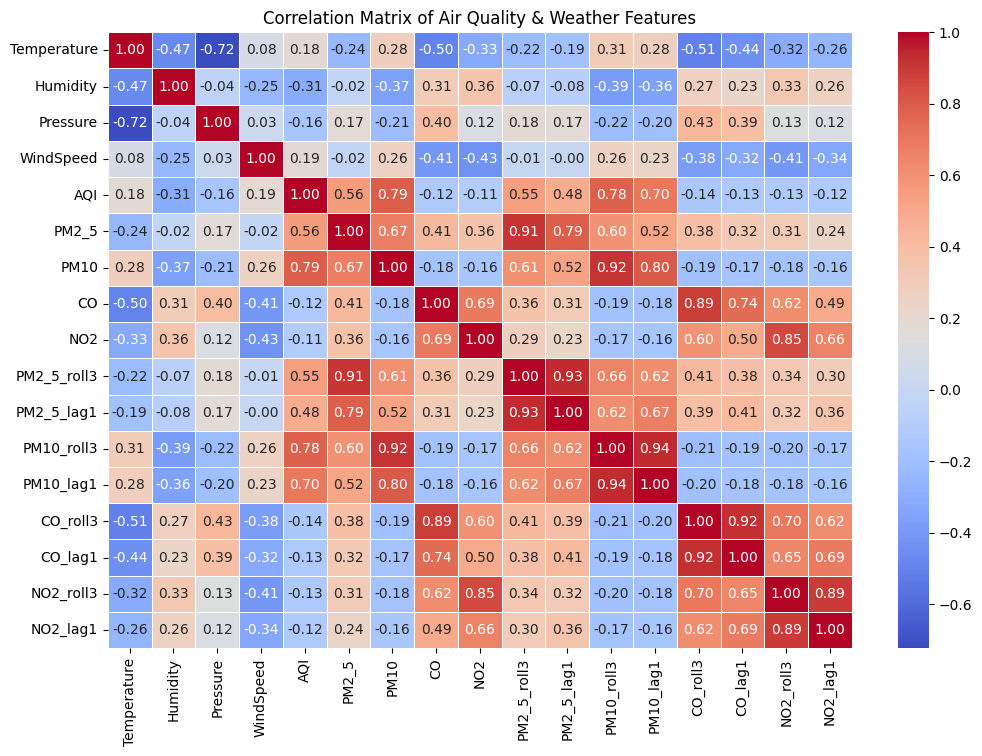

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Air Quality & Weather Features")
plt.show()



In [ ]:
X = df.drop(['AQI','AQI_Category','Date'], axis=1)
y = df['AQI']

split = int(0.8 * len(df))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)


In [ ]:
y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))

y_pred2 = gbr.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))
print("R² :", r2_score(y_test, y_pred2))

MAE : 97.8571011901992
RMSE: 198.47318850874683
R² : 0.5887648281509426
MAE : 95.07364207558118
RMSE: 183.19847812424803
R² : 0.6496272828053626


In [ ]:
svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(
        kernel='rbf',
        C=100,
        epsilon=0.1,
        gamma='scale'
    ))
])

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

In [ ]:
print("📌 SVR Performance")
print("MAE  :", mean_absolute_error(y_test, y_pred_svr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print("R²   :", r2_score(y_test, y_pred_svr))

📌 SVR Performance
MAE  : 94.22597713761924
RMSE : 181.042407426543
R²   : 0.6578258554386023


In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "SVR"],
    "R2": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred2),
        r2_score(y_test, y_pred_svr)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred2),
        mean_absolute_error(y_test, y_pred_svr)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred2)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr))
    ]
})

results


,Model,R2,MAE,RMSE
0,Random Forest,0.588765,97.857101,198.473189
1,Gradient Boosting,0.649627,95.073642,183.198478
2,SVR,0.657826,94.225977,181.042407


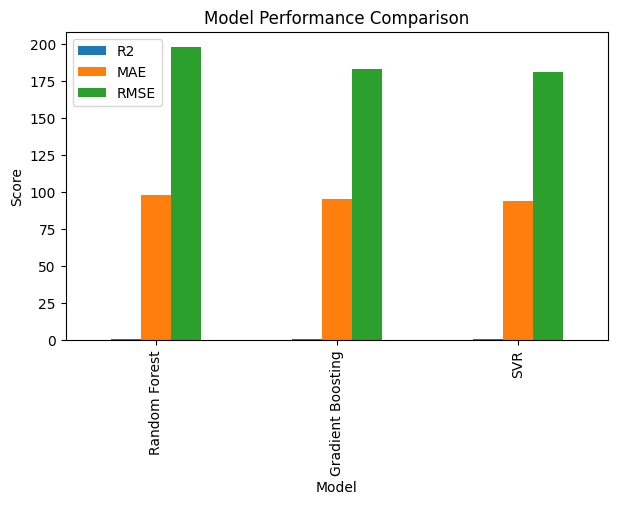

In [ ]:
results.set_index("Model").plot(kind="bar", figsize=(7,4))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

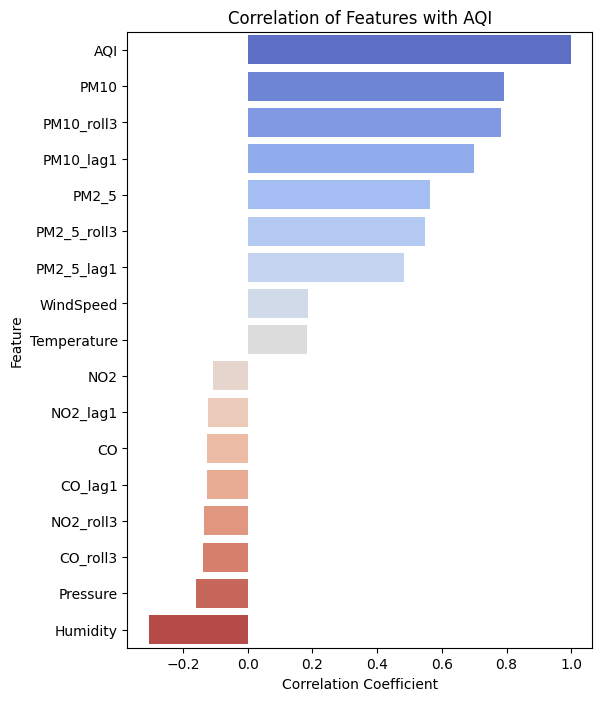

In [ ]:
aqi_corr = corr_matrix['AQI'].sort_values(ascending=False)

plt.figure(figsize=(6,8))
sns.barplot(
    x=aqi_corr.values,
    y=aqi_corr.index,
    palette="coolwarm"
)
plt.title("Correlation of Features with AQI")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()


In [ ]:
high_corr_pairs = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs.head(10)



,,0
PM10_roll3,PM10_lag1,0.937884
PM2_5_roll3,PM2_5_lag1,0.933072
CO_roll3,CO_lag1,0.922415
PM10,PM10_roll3,0.918468
PM2_5,PM2_5_roll3,0.911764
NO2_roll3,NO2_lag1,0.894471
CO,CO_roll3,0.886920
NO2,NO2_roll3,0.853133
PM10,PM10_lag1,0.801229
AQI,PM10,0.792456


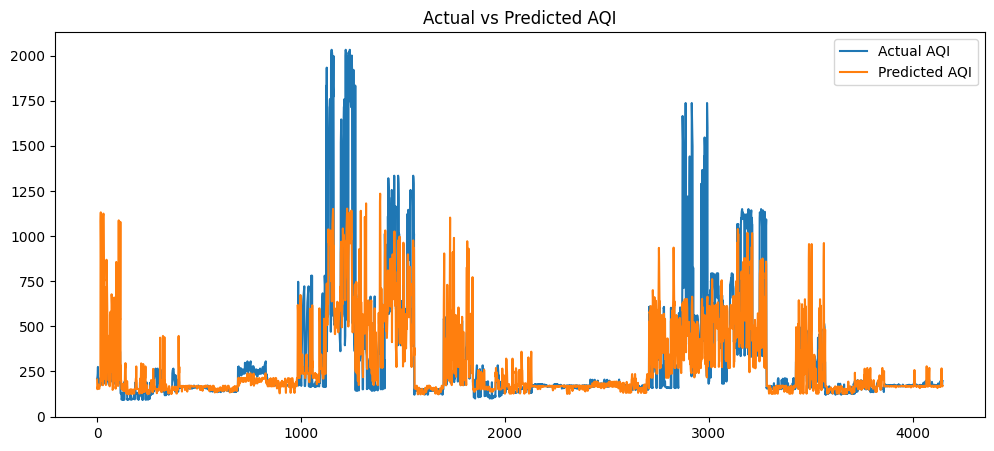

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual AQI')
plt.plot(y_pred, label='Predicted AQI')
plt.legend()
plt.title('Actual vs Predicted AQI')
plt.show()


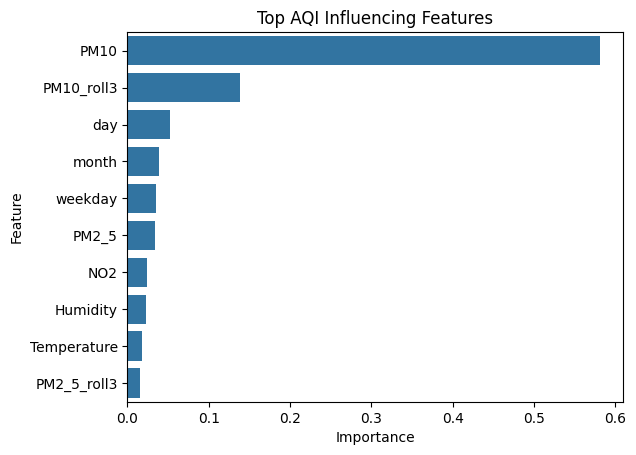

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbr.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title('Top AQI Influencing Features')
plt.show()


In [ ]:
#EARLY WARNING SYSTEM
latest_sample = X.iloc[-1:]
predicted_aqi = gbr.predict(latest_sample)[0]

print("Predicted AQI:", int(predicted_aqi))
print("Category:", aqi_category(predicted_aqi))

if predicted_aqi > 150:
    print("⚠️ ALERT: Unhealthy air quality expected")
else:
    print("✅ Air quality expected to be safe")


Predicted AQI: 216
Category: Very Unhealthy
⚠️ ALERT: Unhealthy air quality expected


In [ ]:
y_pred = gbr.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("📊 Model Performance on Test Set")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

📊 Model Performance on Test Set
MAE  : 95.07
MSE  : 33561.68
RMSE : 183.20
R²   : 0.650


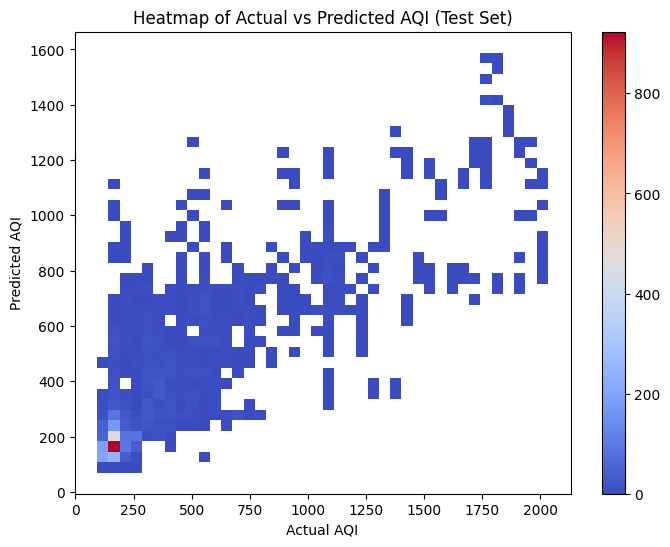

In [ ]:
plt.figure(figsize=(8, 6))

sns.histplot(
    x=y_test,
    y=y_pred,
    bins=40,
    cmap="coolwarm",
    cbar=True
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Heatmap of Actual vs Predicted AQI (Test Set)")
plt.show()

In [ ]:
plt.figure(figsize=(16, 12))
plt.style.use('seaborn-v0_8-whitegrid')

<Figure size 1600x1200 with 0 Axes>

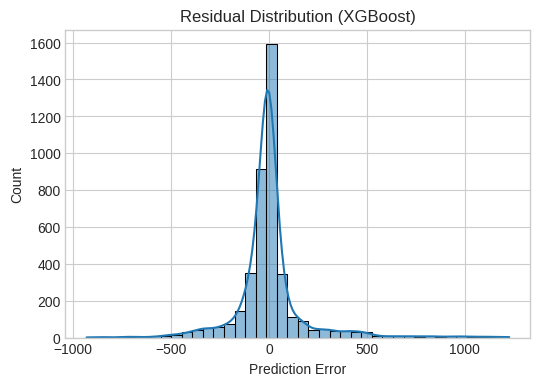

In [ ]:
residuals = y_test - y_pred2

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution (XGBoost)")
plt.xlabel("Prediction Error")
plt.show()
